In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Use DejaVu Serif as an alternative to Times New Roman
rcParams['font.family'] = 'DejaVu Serif'
rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 14
rcParams['axes.labelsize'] = 12
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 10

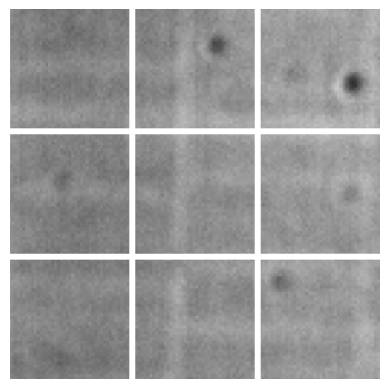

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def split_into_tokens(image, grid_size=(3, 3)):
    h, w, _ = image.shape
    token_h = h // grid_size[0]
    token_w = w // grid_size[1]
    
    tokens = []
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            y0 = i * token_h
            x0 = j * token_w
            token = image[y0:y0 + token_h, x0:x0 + token_w]
            tokens.append(token)
    return tokens

def plot_tokens(tokens, grid_size=(3, 3), spacing=5):
    token_h, token_w, _ = tokens[0].shape
    canvas_h = grid_size[0] * token_h + (grid_size[0] - 1) * spacing
    canvas_w = grid_size[1] * token_w + (grid_size[1] - 1) * spacing
    
    canvas = np.ones((canvas_h, canvas_w, 3), dtype=np.uint8) * 255  # white background

    for idx, token in enumerate(tokens):
        i = idx // grid_size[1]
        j = idx % grid_size[1]
        y = i * (token_h + spacing)
        x = j * (token_w + spacing)
        canvas[y:y + token_h, x:x + token_w] = token
    
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    # Save the figure with no borders or padding
    plt.savefig("tokens_plot_1.png", bbox_inches='tight', pad_inches=0)
    plt.show()

# Example usage:
image = cv2.imread('in.png')  # Replace with your image path
image = cv2.resize(image, (300, 300))  # Make divisible by 3x3
tokens = split_into_tokens(image)
plot_tokens(tokens)

In [4]:
import cv2
import numpy as np

def split_into_tokens(image, grid_size=(3, 3)):
    h, w, _ = image.shape
    token_h = h // grid_size[0]
    token_w = w // grid_size[1]
    
    tokens = []
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            y0 = i * token_h
            x0 = j * token_w
            token = image[y0:y0 + token_h, x0:x0 + token_w]
            tokens.append(token)
    return tokens

def save_flat_tokens_image(tokens, spacing=5, save_path="flat_tokens.jpg"):
    token_h, token_w, _ = tokens[0].shape
    num_tokens = len(tokens)

    # Width includes spacing between tokens but not around edges
    total_w = num_tokens * token_w + (num_tokens - 1) * spacing
    canvas = np.ones((token_h, total_w, 3), dtype=np.uint8) * 255  # white background

    for idx, token in enumerate(tokens):
        x = idx * (token_w + spacing)
        canvas[:, x:x + token_w] = token

    cv2.imwrite(save_path, canvas)


# Example usage
image = cv2.imread('in.png') # Replace with your image path
image = cv2.resize(image, (300, 300))  # Ensure divisible by 3
tokens = split_into_tokens(image)
save_flat_tokens_image(tokens, spacing=5, save_path="flat_token_strip.jpg")


In [5]:
results_yz = np.load("/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_Regression_zy_2025-08-05_12-03-23/results.npz")
loss_log = results_yz['loss_log']
predictions = results_yz['predictions']
gt_size_labels = results_yz['ground_truth_sizes']
size_labels = results_yz['size_labels']
import matplotlib.pyplot as plt
import numpy as np

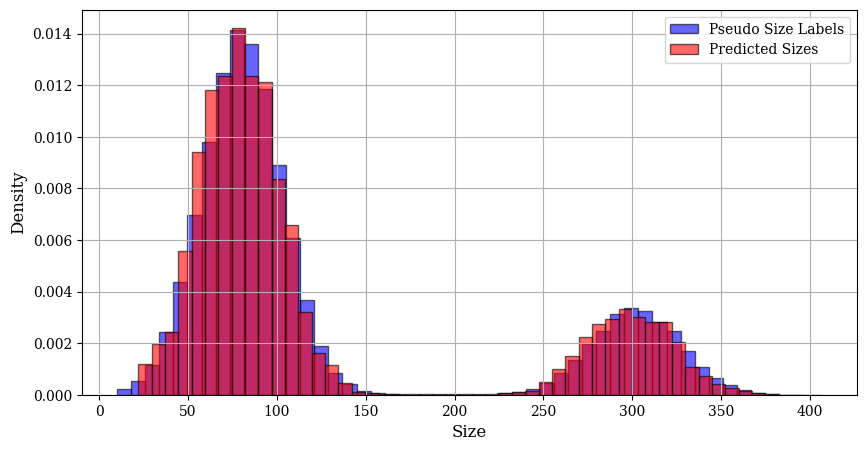

In [6]:
def plot_distribution(predictions, gt_size_labels, size_labels, save_path="size_distribution.png"):
    plt.figure(figsize=(10, 5))
    plt.hist(gt_size_labels, bins=50, alpha=0.6, label='Pseudo Size Labels', color='blue', edgecolor='black',density=True)
    plt.hist(predictions, bins=50, alpha=0.6, label='Predicted Sizes', color='red', edgecolor='black',density=True)
    plt.xlabel('Size')
    plt.ylabel('Density')
    plt.grid()
    plt.legend()
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()  
    plt.close()

plot_distribution(predictions, gt_size_labels, size_labels, save_path="size_distribution.png")

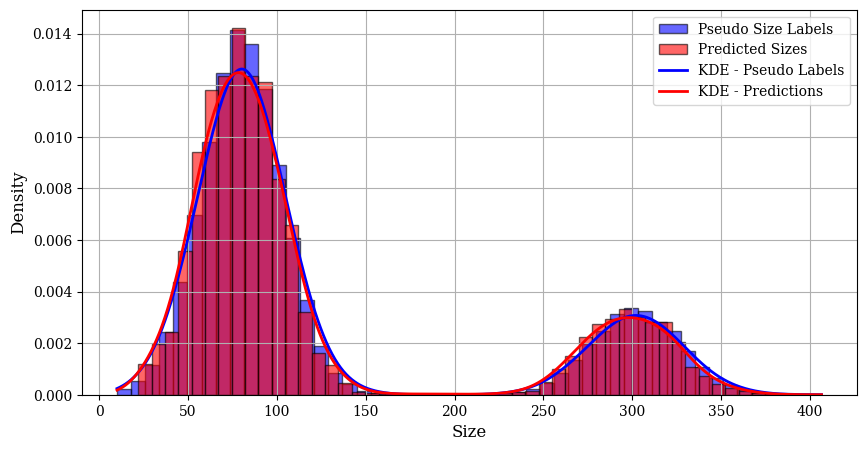

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_distribution(predictions, gt_size_labels, size_labels, save_path="size_distribution.png"):
    plt.figure(figsize=(10, 5))

    # Plot histograms
    plt.hist(gt_size_labels, bins=50, alpha=0.6, label='Pseudo Size Labels', color='blue', edgecolor='black', density=True)
    plt.hist(predictions, bins=50, alpha=0.6, label='Predicted Sizes', color='red', edgecolor='black', density=True)

    # Fit and plot KDE curves
    x_min = min(min(gt_size_labels), min(predictions))
    x_max = max(max(gt_size_labels), max(predictions))
    x_vals = np.linspace(x_min, x_max, 1000)

    kde_gt = gaussian_kde(gt_size_labels)
    kde_pred = gaussian_kde(predictions)

    plt.plot(x_vals, kde_gt(x_vals), color='blue', linewidth=2, label='KDE - Pseudo Labels')
    plt.plot(x_vals, kde_pred(x_vals), color='red', linewidth=2, label='KDE - Predictions')

    plt.xlabel('Size')
    plt.ylabel('Density')
    plt.grid()
    plt.legend()
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

# Example usage:
plot_distribution(predictions, gt_size_labels, size_labels, save_path="size_distribution_KDE.png")


In [19]:
import h5py
import numpy as np
h5_paths = [
    "/scratch/narjis/iscat_data/brightfield_particles_x.hdf5",  
    "/scratch/narjis/iscat_data/brightfield_particles_y.hdf5",
    "/scratch/narjis/iscat_data/particles_3d_mf.hdf5"
]
sample_images = []  
for h5_path in h5_paths:
    # Take one sample image the first one
    with h5py.File(h5_path, "r") as h5_file:
        image = h5_file['data'][21]
        sample_images.append(image)
        print(image.shape)
volume_particle = (sample_images[-1] - np.min(sample_images[-1])) / (np.max(sample_images[-1]) - np.min(sample_images[-1]))
XZ = sample_images[0]
YZ = sample_images[1]

(16, 201)
(16, 201)
(201, 16, 16)


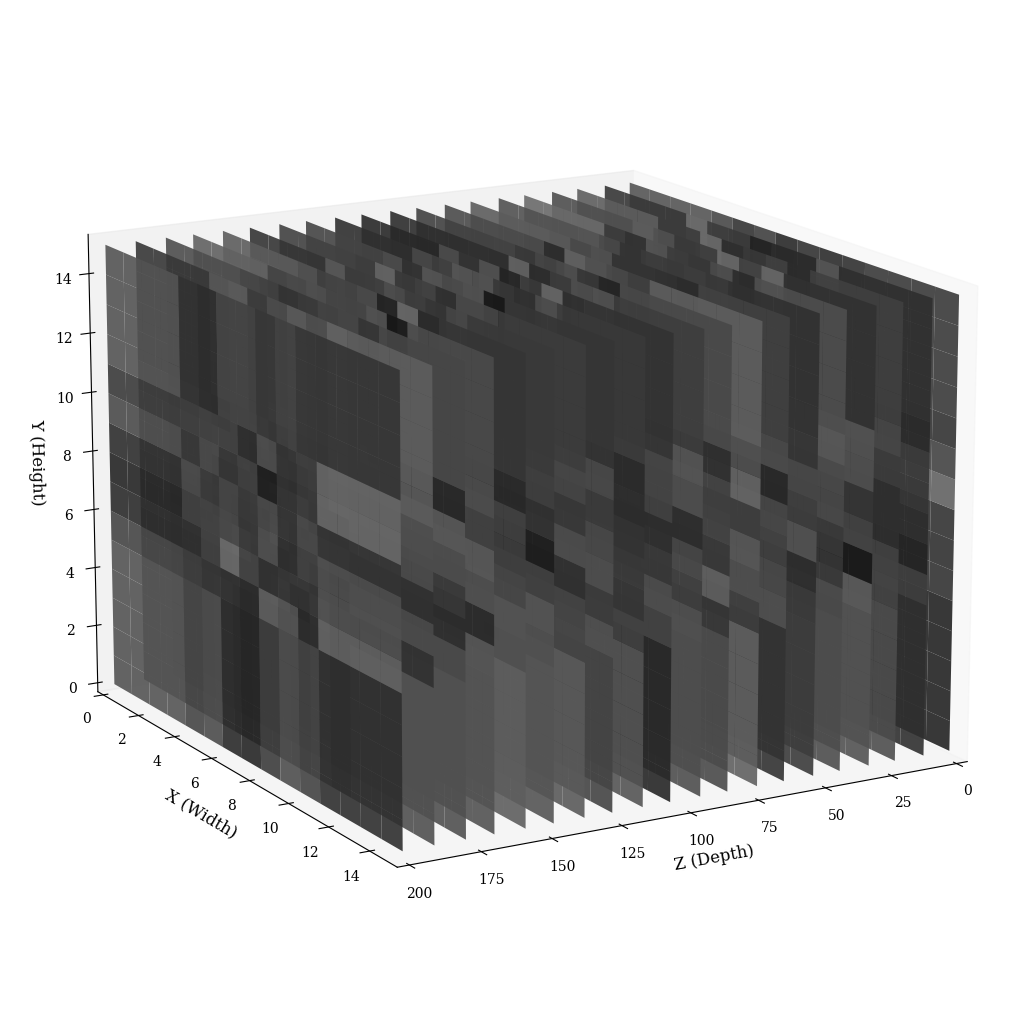

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_chunks(img, num_chunks=6):
    """
    Plot evenly spaced chunks from a 3D image as grayscale slices in 3D space.
    Args:
        img: numpy array of shape (201, 16, 16)
        num_chunks: number of chunks to plot (default: 6)
    Returns:
        chunk_indices: array of depth indices that were plotted
    """
    depth, height, width = img.shape
    
    # Calculate evenly spaced indices for chunks
    chunk_indices = np.linspace(0, depth - 1, num_chunks, dtype=int)
    
    # Create 3D plot with tight layout
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(projection='3d')
    
    # Create coordinate grids for plotting
    x = np.arange(width)
    y = np.arange(height)
    X, Y = np.meshgrid(x, y)
    
    # Plot each chunk
    for i, z_idx in enumerate(chunk_indices):
        # Get the 16x16 slice at depth z_idx
        slice_2d = img[z_idx, :, :]
        
        # Create X coordinate plane for this slice (horizontal progression)
        Z_plane = np.full_like(Y, z_idx, dtype=float)
        
        # Plot the surface rotated to be horizontal with grayscale colormap
        surf = ax.plot_surface(Z_plane, X, Y, facecolors=plt.cm.gray(slice_2d/slice_2d.max()),
                             alpha=0.9, linewidth=0, antialiased=True)
    
    # Set labels and title
    ax.set_xlabel('Z (Depth)')
    ax.set_ylabel('X (Width)')
    ax.set_zlabel('Y (Height)')
    ax.grid(False)
    
    # Set the viewing angle for better horizontal visualization
    ax.view_init(elev=15, azim=60)
    
    # Remove all whitespace and padding
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
    
    # Remove axes margins
    ax.margins(0)
    
    # Make the axes fill the entire figure
    ax.set_position([0, 0, 1, 1])
    
    
    # Save the figure with no whitespace
    plt.savefig("3d_chunks_plot.png", bbox_inches='tight', pad_inches=0, 
                facecolor='white', edgecolor='none', dpi=150)
    
    # Show the plot
    plt.show()

plot_3d_chunks(volume_particle, num_chunks=20)

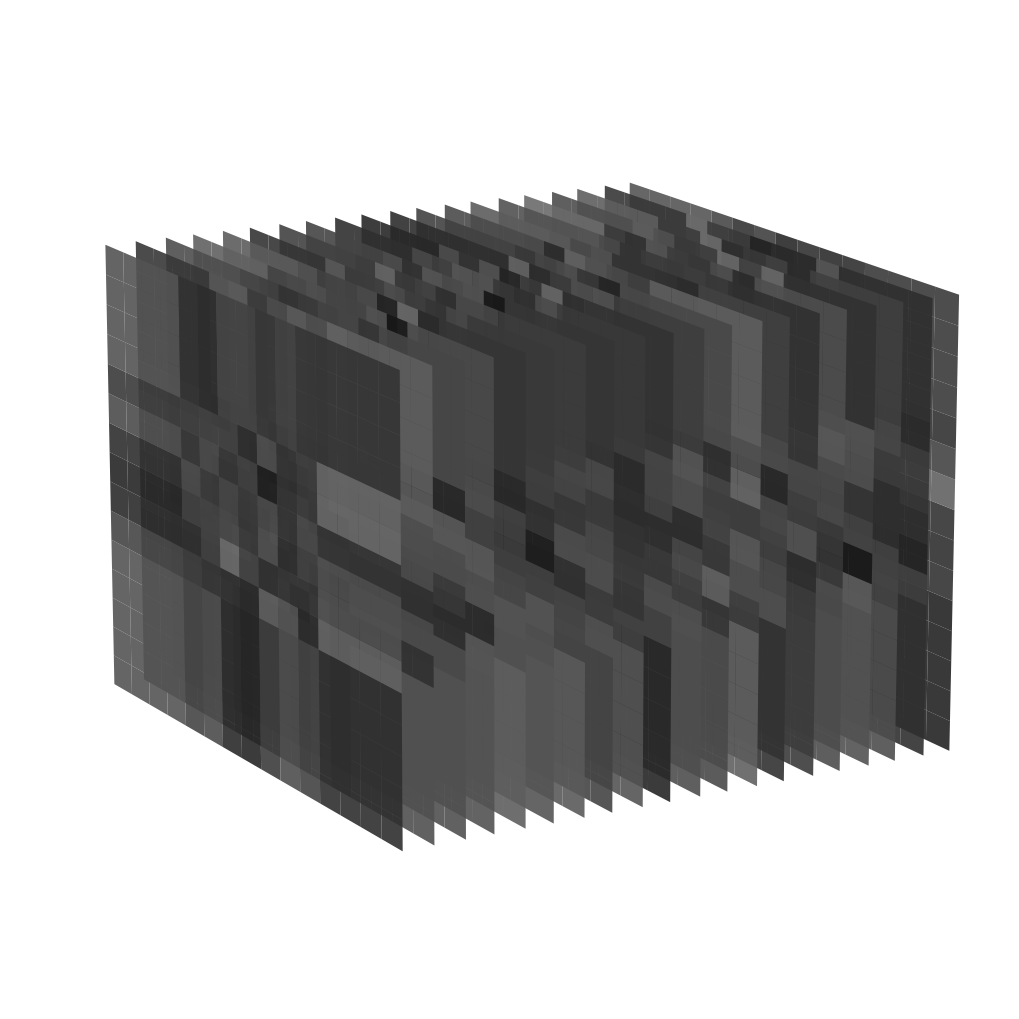

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_chunks_no_axis(img, num_chunks=6):
    """
    Plot evenly spaced chunks from a 3D image as grayscale slices in 3D space.
    Args:
        img: numpy array of shape (201, 16, 16)
        num_chunks: number of chunks to plot (default: 6)
    Returns:
        chunk_indices: array of depth indices that were plotted
    """
    depth, height, width = img.shape
    
    # Calculate evenly spaced indices for chunks
    chunk_indices = np.linspace(0, depth - 1, num_chunks, dtype=int)
    
    # Create 3D plot with tight layout
    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(projection='3d')
    
    # Create coordinate grids for plotting
    x = np.arange(width)
    y = np.arange(height)
    X, Y = np.meshgrid(x, y)
    
    # Plot each chunk
    for i, z_idx in enumerate(chunk_indices):
        # Get the 16x16 slice at depth z_idx
        slice_2d = img[z_idx, :, :]
        
        # Create X coordinate plane for this slice (horizontal progression)
        Z_plane = np.full_like(Y, z_idx, dtype=float)
        
        # Plot the surface rotated to be horizontal with grayscale colormap
        surf = ax.plot_surface(Z_plane, X, Y, facecolors=plt.cm.gray(slice_2d/slice_2d.max()),
                             alpha=0.9, linewidth=0, antialiased=True)
    
    # Set labels and title
    ax.grid(False)
    ax.set_xticks([])  # Remove x-axis ticks
    ax.set_yticks([])
    ax.set_zticks([])  # Remove z-axis ticks
    # axis off
    ax.set_axis_off()
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.xaxis.pane.set_visible(False)
    ax.yaxis.pane.set_visible(False)
    ax.zaxis.pane.set_visible(False)

    # Set the viewing angle for better horizontal visualization
    ax.view_init(elev=15, azim=60)
    
    # Remove all whitespace and padding
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
    
    # Remove axes margins
    ax.margins(0)
    
    # Make the axes fill the entire figure
    ax.set_position([0, 0, 1, 1])
    
    
    # Save the figure with no whitespace
    plt.savefig("3d_chunks_plot_no_axis.png", bbox_inches='tight', pad_inches=0, 
                facecolor='white', edgecolor='none', dpi=150)
    
    # Show the plot
    plt.show()

plot_3d_chunks_no_axis(volume_particle, num_chunks=20)

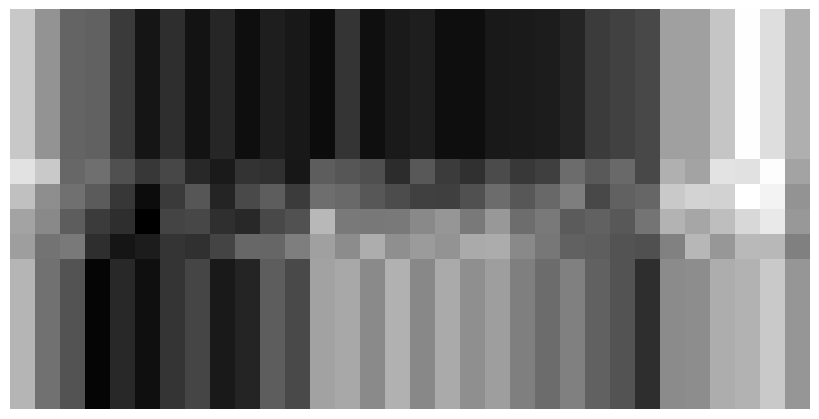

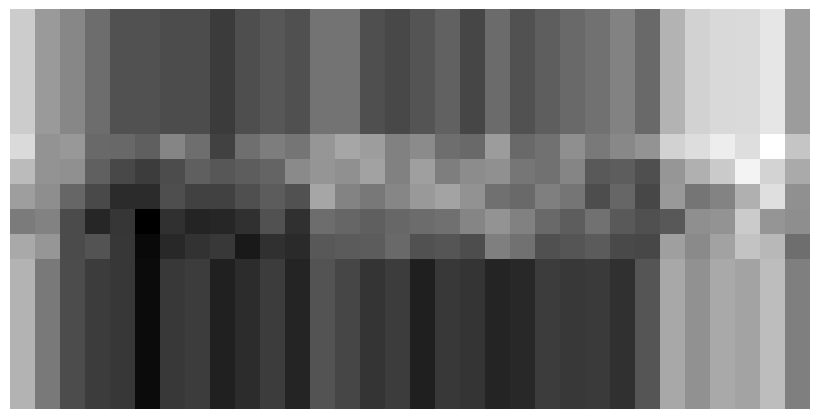

In [20]:
# plot the yz and xz slices
import matplotlib.pyplot as plt
import numpy as np
import cv2  
def plot_slices(slice, save_path=None):
    # downsample the slice to 16x32
    slice_resized = cv2.resize(slice, (32, 16))  
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('off')
    ax.imshow(slice_resized, cmap='gray') 
    
    # Remove margins so image fills the figure
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    if save_path:
        plt.savefig(
            save_path, 
            bbox_inches='tight',  # removes bounding box whitespace
            pad_inches=0,         # removes padding
            dpi=300               # optional: adjust resolution
        )
    plt.show()

plot_slices(XZ, save_path='xz_slice.png')
plot_slices(YZ, save_path='yz_slice.png')

In [9]:
import os
os.chdir("..")

In [90]:
import torch
import torch.nn as nn
class ResNet18_MMD(nn.Module):
    def __init__(self, num_classes=1,in_channels=1):    
        super(ResNet18_MMD, self).__init__()
        self.resnet = torch.hub.load(
            "pytorch/vision:v0.10.0", "resnet18", pretrained=False
        )
        self.resnet.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        )
        self.resnet.fc = nn.Sequential(
                nn.Linear(self.resnet.fc.in_features, self.resnet.fc.in_features),
                nn.ReLU(),
                nn.Linear(self.resnet.fc.in_features, num_classes)
            )       
    def forward(self, x):
        return self.resnet(x)
    
class ResNet18_KNN(nn.Module):
    def __init__(self, num_classes=1,in_channels=1,dropout_rate=0):
        super(ResNet18_KNN, self).__init__()
        self.resnet = torch.hub.load(
            "pytorch/vision:v0.10.0", "resnet18", pretrained=False
        )
        self.resnet.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        )
        self.size_head = nn.Linear(self.resnet.fc.in_features, num_classes)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.resnet.fc = nn.Identity() 
    def forward(self, x):
        features = self.resnet(x)
        features = self.dropout(features)
        size_output = self.size_head(features)       
        return size_output
class ResNet18_Reg(nn.Module):
    def __init__(self, num_classes=1,in_channels=1,dropout_rate=0.5):
        super(ResNet18_Reg, self).__init__()
        self.resnet = torch.hub.load(
            "pytorch/vision:v0.10.0", "resnet18", pretrained=False
        )
        self.resnet.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        )
         # Remove the original fully connected layer
        # self.size_head = nn.Sequential(
        #     nn.Linear(self.resnet.fc.in_features, self.resnet.fc.in_features),
        #     nn.ReLU(),
        #     nn.Linear(self.resnet.fc.in_features, num_classes)
        # )
        self.size_head = nn.Linear(self.resnet.fc.in_features, num_classes)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.resnet.fc = nn.Identity() 
    def forward(self, x):
        features = self.resnet(x)
        features = self.dropout(features)
        size_output = self.size_head(features)       
        return size_output

model_paths =[
    "/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_KNN_loss/best_model.pth",
    "/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_MMD/best_model.pth",
    "/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_Regression_weak_supervised/best_model.pth"
]
# model_paths =[
#     "/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_KNN_loss/best_model.pth",
#     "/home/zakarianarjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_MMD/best_model.pth"
# ]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load the model

model_knn = ResNet18_KNN().to(device)
model_mmd = ResNet18_MMD().to(device)
model_reg = ResNet18_Reg().to(device)  # Uncommenting the model_reg initialization
models = [model_knn, model_mmd, model_reg]  # Adding model_reg back to the models list
for checkpoint_path,model in zip(model_paths, models):
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device,weights_only=True)['model_state_dict'])
        model.eval()
    else:
        print(f"Model file {checkpoint_path} does not exist. Please check the path.")

Using cache found in /home/zakarianarjis/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /home/zakarianarjis/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /home/zakarianarjis/.cache/torch/hub/pytorch_vision_v0.10.0


In [ ]:
from src.data_processing.size_dataset import ParticleDataset,ParticleDatasetReg
from torch.utils.data import DataLoader
h5_path = "/scratch/narjis/iscat_data/brightfield_particles_y.hdf5"
train_dataset = ParticleDataset(
    h5_path=h5_path,
    classes=[0,1],
    transform=None,
    mean=None,
    std=None,
    padding=None,
    indices=None,
)
train_dataset_reg = ParticleDatasetReg(
    h5_path=h5_path,
    classes=[0,1],
    transform=None,
    mean=None,
    std=None,
    indices=None,
)
def create_dataloaders(train_dataset, batch_size, num_workers=0):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
    )
    return train_loader


import torch
import numpy as np
import matplotlib.pyplot as plt
def predict(model, dataset, device):
    model.eval()
    predictions = []
    dataloader = create_dataloaders(dataset, batch_size=1024, num_workers=0)
    with torch.no_grad():
        for batch in dataloader:
            if isinstance(model, ResNet18_KNN) or isinstance(model, ResNet18_MMD):
                inputs, _ = batch
            else:
                inputs, _, _ = batch  # For ResNet18_Reg, we expect three outputs
            inputs = inputs.to(device)
            outputs = model(inputs)
            outputs = outputs.cpu().numpy()
            
            predictions.extend(outputs.flatten())            
    # Convert to numpy arrays
    predictions = np.array(predictions)
    return predictions
predictions_knn = predict(model_knn, train_dataset, device)
predictions_mmd = predict(model_mmd, train_dataset, device)
predictions_reg = predict(model_reg, train_dataset_reg, device)

Computed statistics: mean = 7541.1983, std = 1316.1215
Computed statistics: mean = 7541.1983, std = 1316.1215


: 

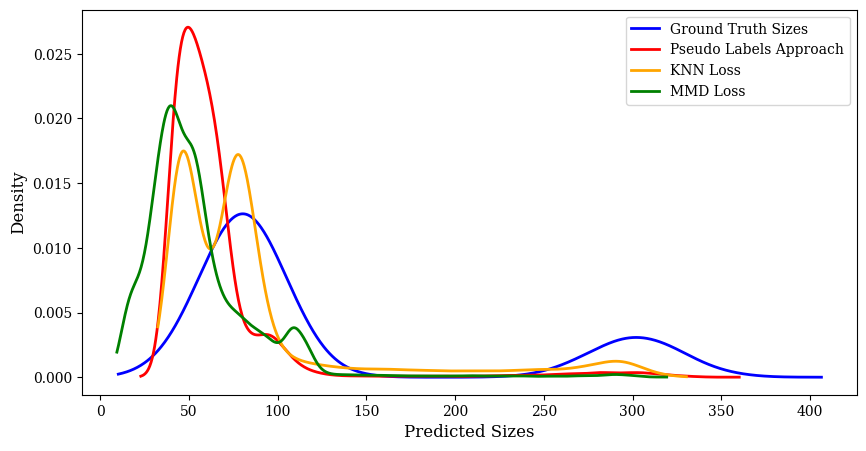

In [96]:
# visualize all approaches distribution with KDE without histogram
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
def plot_predictions(predictions_knn, predictions_mmd, prediction_supervised_approach, gt_size_labels):
    plt.figure(figsize=(10, 5))
    # Plot KDE for ground truth sizes
    kde_gt = gaussian_kde(gt_size_labels)
    x_gt = np.linspace(min(gt_size_labels), max(gt_size_labels), 1000)
    plt.plot(x_gt, kde_gt(x_gt), color='blue', label='Ground Truth Sizes', linewidth=2)
    
    # Plot KDE for supervised approach predictions
    kde_supervised = gaussian_kde(prediction_supervised_approach)
    x_supervised = np.linspace(min(prediction_supervised_approach), max(prediction_supervised_approach), 1000)
    plt.plot(x_supervised, kde_supervised(x_supervised), color='red', label='Pseudo Labels Approach', linewidth=2)

    # Plot KDE for KNN predictions
    kde_knn = gaussian_kde(predictions_knn)
    x_knn = np.linspace(min(predictions_knn), max(predictions_knn), 1000)
    plt.plot(x_knn, kde_knn(x_knn), color='orange', label='KNN Loss', linewidth=2)
    
    # Plot KDE for MMD predictions
    kde_mmd = gaussian_kde(predictions_mmd)
    x_mmd = np.linspace(min(predictions_mmd), max(predictions_mmd), 1000)
    plt.plot(x_mmd, kde_mmd(x_mmd), color='green', label='MMD Loss', linewidth=2)
    plt.xlabel('Predicted Sizes')
    plt.ylabel('Density')
    plt.legend()
    plt.savefig("Benchmark_size_prediction.png", bbox_inches='tight', dpi=300)
    plt.show()
    
plot_predictions(predictions_knn, predictions_mmd, predictions_reg, gt_size_labels)

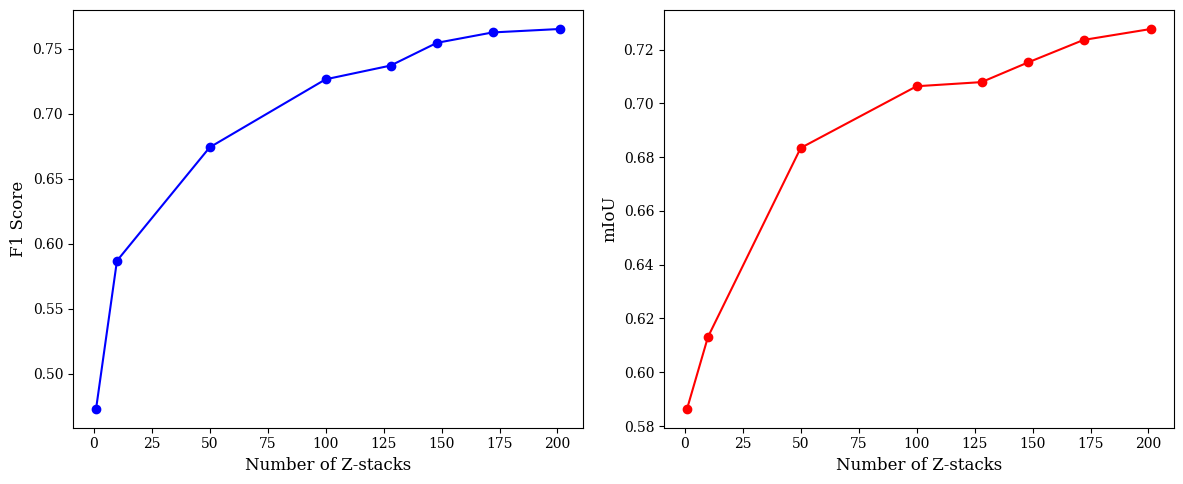

Found 8 experiments
Z-stacks: 1, F1: 0.473, mIoU: 0.586
Z-stacks: 10, F1: 0.587, mIoU: 0.613
Z-stacks: 50, F1: 0.674, mIoU: 0.683
Z-stacks: 100, F1: 0.726, mIoU: 0.706
Z-stacks: 128, F1: 0.737, mIoU: 0.708
Z-stacks: 148, F1: 0.755, mIoU: 0.715
Z-stacks: 172, F1: 0.763, mIoU: 0.724
Z-stacks: 201, F1: 0.765, mIoU: 0.728


In [28]:
import os
import json
import yaml
import matplotlib.pyplot as plt

base_path = "/home/zakarianarjis/workspace/iscat/experiments/runs/segmentation/commercial_beads/"
results = []

for folder in os.listdir(base_path):
    if 'slice' not in folder.lower():
        continue
        
    folder_path = os.path.join(base_path, folder)
    
    # Find JSON file
    json_files = [f for f in os.listdir(folder_path) if f.endswith('.json')]
    if not json_files:
        continue
    
    # Load JSON
    with open(os.path.join(folder_path, json_files[0]), 'r') as f:
        data = json.load(f)
    
    # Load config
    with open(os.path.join(folder_path, 'config.yaml'), 'r') as f:
        config = yaml.safe_load(f)
    
    results.append({
        'slices': config['data']['num_z_slices'],
        'f1': data['detection_scores']['total_f1'],
        'miou': data['segmentation_scores']['mIoU']
    })

results.sort(key=lambda x: x['slices'])

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

slices = [r['slices'] for r in results]
f1_scores = [r['f1'] for r in results]
miou_scores = [r['miou'] for r in results]

ax1.plot(slices, f1_scores, 'bo-')
ax1.set_xlabel('Number of Z-stacks')
ax1.set_ylabel('F1 Score')


ax2.plot(slices, miou_scores, 'ro-')
ax2.set_xlabel('Number of Z-stacks')
ax2.set_ylabel('mIoU')


plt.tight_layout()
plt.savefig("z-stacks_benchmark.png", bbox_inches='tight', dpi=300)
plt.show()

print(f"Found {len(results)} experiments")
for r in results:
    print(f"Z-stacks: {r['slices']}, F1: {r['f1']:.3f}, mIoU: {r['miou']:.3f}")

In [79]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Function to extract averaged frames ---
def extract_averaged_frames(image, num_frames=12):
    """
    Extracts the average of evenly spaced frame chunks from a 3D image.

    Parameters:
        image (numpy.ndarray): 3D image with shape (Z, H, W)
        num_frames (int): Number of frames to extract

    Returns:
        numpy.ndarray: 3D array of extracted averaged frames with shape (num_frames, H, W)
    """
    z_len = image.shape[0]
    chunk_size = z_len // num_frames

    averaged_frames = []
    for i in range(num_frames):
        start = i * chunk_size
        end = start + chunk_size
        chunk = image[start:end]
        averaged_frames.append(np.mean(chunk, axis=0))

    return np.array(averaged_frames)

# --- Function to plot 3D chunks ---

def plot_3d_chunks_no_axis(img):
    """
    Plot slices from a 3D image as grayscale surfaces in 3D space without white grid lines.
    Uses global normalization so brightness is consistent across slices.
    """
    depth, height, width = img.shape
    chunk_indices = np.arange(depth)

    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(projection='3d')

    x = np.arange(width)
    y = np.arange(height)
    X, Y = np.meshgrid(x, y)

    # Global normalization
    mean, std= img.mean(), img.std()

    for z_idx in chunk_indices:
        slice_2d = img[z_idx, :, :]
        # normalize this slice globally
        norm_slice = (slice_2d - mean) / std
        Z_plane = np.full_like(Y, z_idx, dtype=float)

        ax.plot_surface(Z_plane, X, Y,
                        facecolors=plt.cm.gray(norm_slice),
                        linewidth=0, antialiased=False,
                        rstride=1, cstride=1)

    ax.grid(False)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_axis_off()
    ax.view_init(elev=15, azim=60)
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.show()


# --- Load HDF5 and extract one sample ---
hdf5_path = "/scratch/narjis/iscat_data/brightfield.hdf5"
with h5py.File(hdf5_path, "r") as f:
    # Assuming the dataset key is 'data'; adjust if different
    dataset_keys = list(f.keys())
    print("Available datasets:", dataset_keys)
    idx = 1
    sample_image = f[dataset_keys[0]][idx]
    mask = f[dataset_keys[1]][idx][0]

# --- Compute 32 averaged frames ---
averaged_image = (sample_image - np.mean(sample_image)) / (np.std(sample_image))
averaged_image = extract_averaged_frames(averaged_image, num_frames=32)

# --- Plot 3D averaged image ---
# plot_3d_chunks_no_axis(averaged_image)

Available datasets: ['image_patches', 'mask_patches']


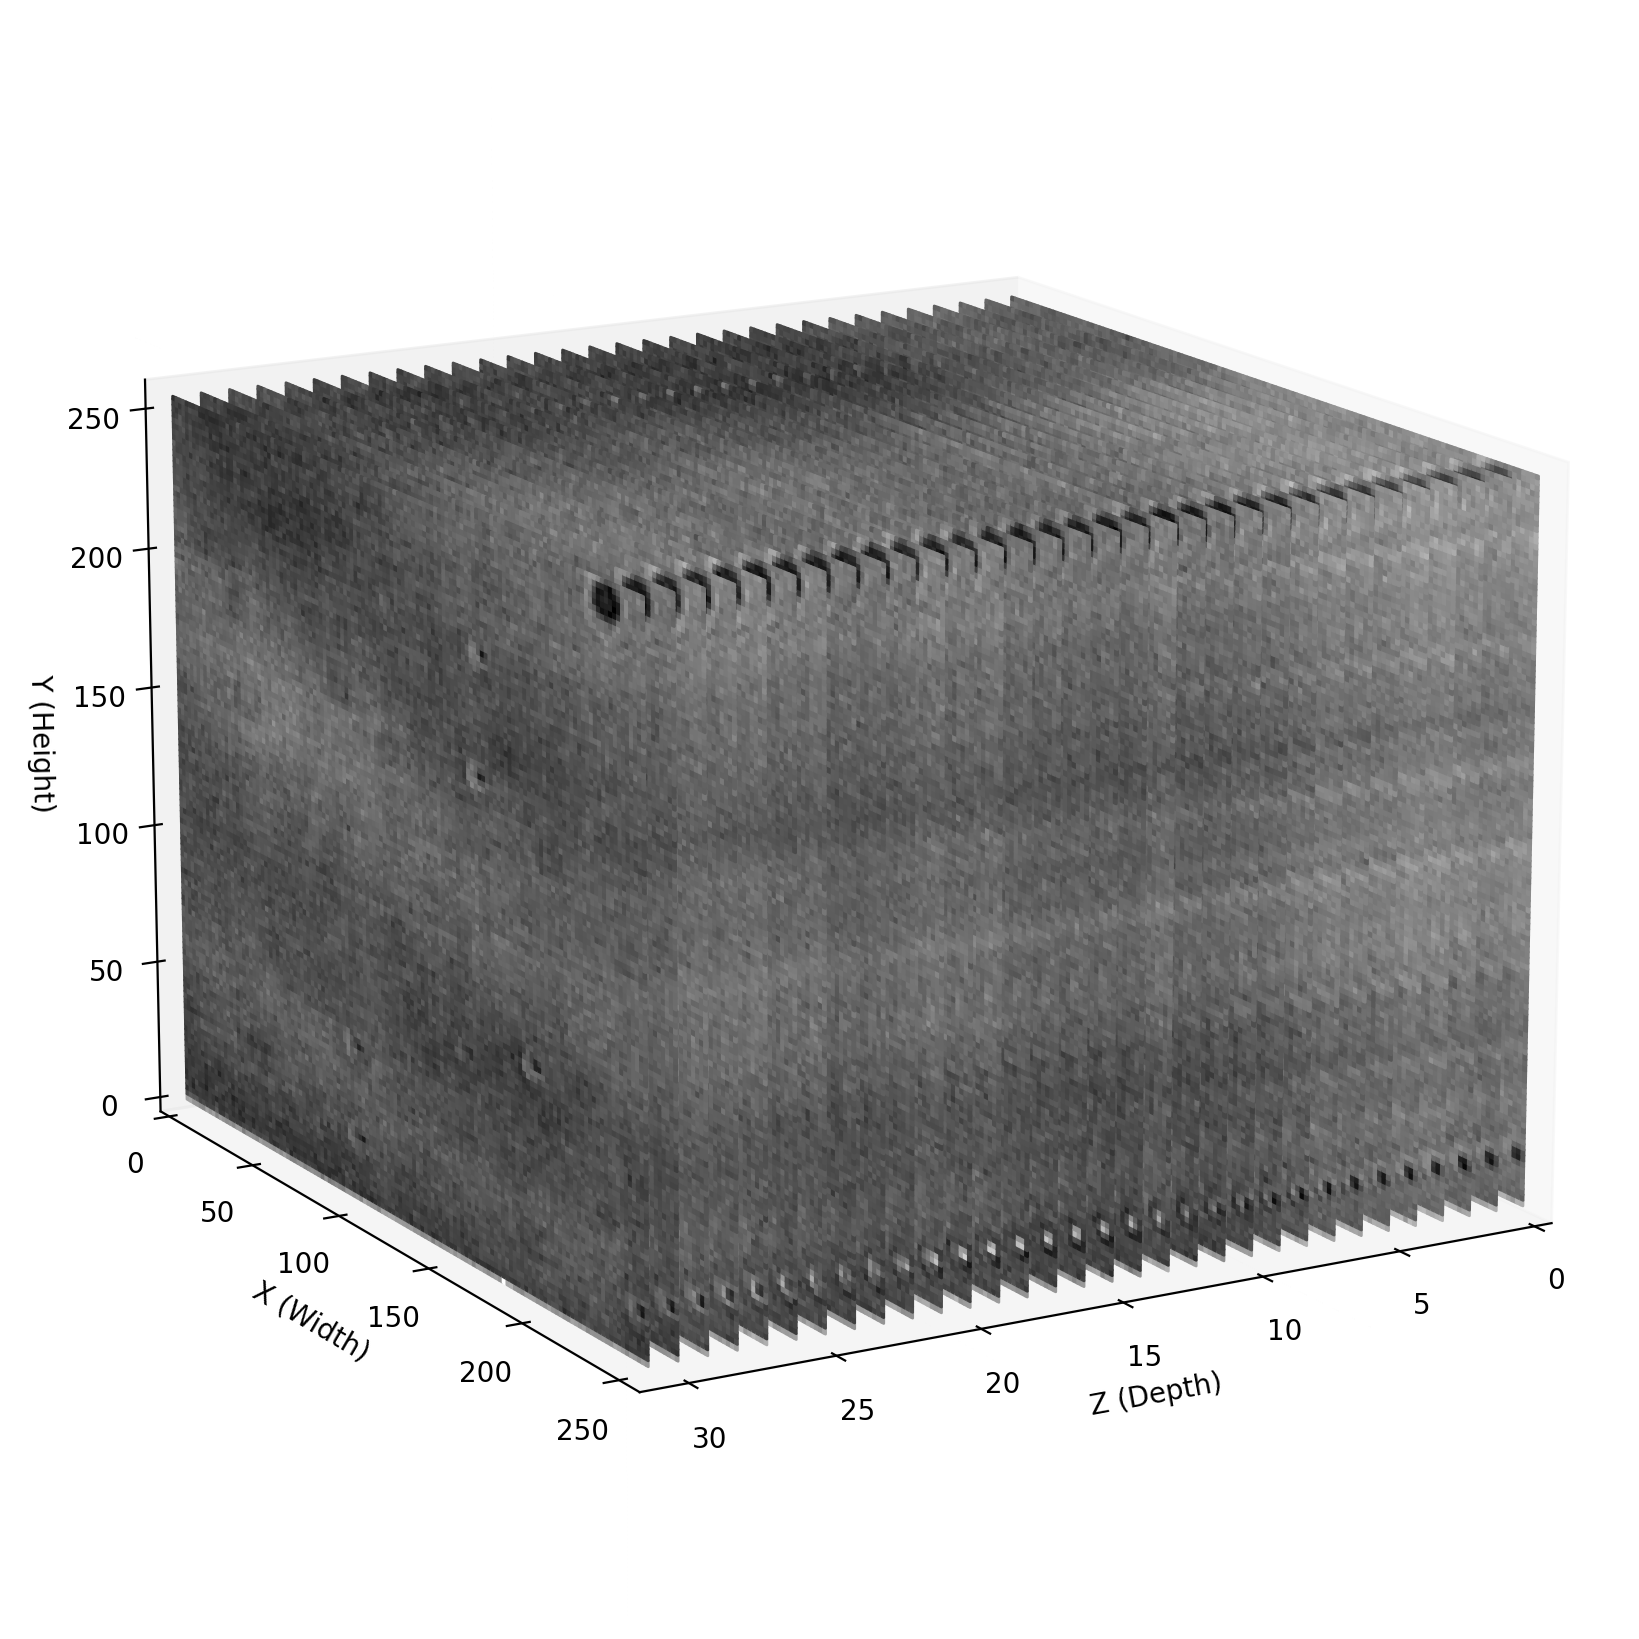

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# averaged_image has shape (32, 256, 256)
z_slices, h, w = averaged_image.shape

# Increase DPI for higher quality
fig = plt.figure(figsize=(12, 8), dpi=200)  # default is 100, so 200 doubles quality
ax = fig.add_subplot(111, projection='3d')

# We'll put Z-axis along X direction (horizontal)
for z in range(z_slices):
    Y, Z = np.meshgrid(np.arange(h), np.arange(w))  # Y and Z axes
    X = np.ones((h, w)) * z  # X axis is the slice index
    
    slice_img = averaged_image[z]
    slice_img_norm = (slice_img - slice_img.min()) / (slice_img.ptp() + 1e-8)
    
    ax.plot_surface(
        X, Y, Z,
        rstride=2, cstride=2,  # smaller strides improve quality
        facecolors=plt.cm.gray(slice_img_norm),
        shade=False
    )

ax.set_xlabel('Z (Depth)')
ax.set_ylabel('X (Width)')
ax.set_zlabel('Y (Height)')
ax.grid(False)

# Remove all whitespace and padding
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

# Remove axes margins
ax.margins(0)

# Make the axes fill the entire figure
ax.set_position([0, 0, 1, 1])
       

# Keep your original viewing angle
ax.view_init(elev=15, azim=60)

# Optionally save as a high-quality PNG
plt.savefig("3D_seg_image_stack.png", dpi=300, bbox_inches='tight')

plt.show()